"""
Task 1: News Topic Classifier Using BERT

Objective:
Fine-tune bert-base-uncased to classify AG News headlines into four categories:
0 = World
1 = Sports
2 = Business
3 = Sci/Tech

Dataset:
AG News Dataset from Hugging Face Datasets

Evaluation:
Accuracy, F1-score, Classification Report, Confusion Matrix
"""

In [1]:
!pip install -q datasets transformers evaluate accelerate scikit-learn matplotlib seaborn streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 24.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
dataset = load_dataset("/ag_news")

dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

In [10]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

print(dataset["train"][0])
print(dataset["test"][0])

{'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."}
{'label': 3, 'title': 'Fears for T N pension after talks', 'description': "Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul."}


In [11]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

train_df.head()

,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


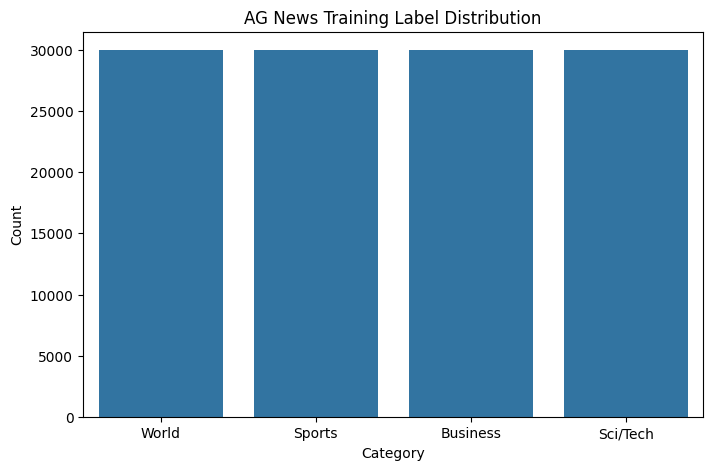

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x=train_df["label"])
plt.xticks(ticks=[0,1,2,3], labels=label_names)
plt.title("AG News Training Label Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [13]:
# For faster Colab training
small_train = dataset["train"].shuffle(seed=42).select(range(10000))
small_test = dataset["test"].shuffle(seed=42).select(range(2000))

small_train, small_test

(Dataset({
     features: ['label', 'title', 'description'],
     num_rows: 10000
 }),
 Dataset({
     features: ['label', 'title', 'description'],
     num_rows: 2000
 }))

In [14]:
model_name = "bert-base-uncased"

tokenizer = BertTokenizerFast.from_pretrained(model_name)

def tokenize_function(example):
    # Combine 'title' and 'description' to create the 'text' for tokenization
    text_to_tokenize = [t + " " + d for t, d in zip(example["title"], example["description"])]
    return tokenizer(
        text_to_tokenize,
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Shift labels from [1, 2, 3, 4] to [0, 1, 2, 3]
def shift_labels(example):
    example["label"] = [l - 1 for l in example["label"]]
    return example

# Apply label shifting
small_train = small_train.map(shift_labels, batched=True)
small_test = small_test.map(shift_labels, batched=True)

# Tokenize
tokenized_train = small_train.map(tokenize_function, batched=True)
tokenized_test = small_test.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["title", "description"])
tokenized_test = tokenized_test.remove_columns(["title", "description"])

tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [16]:
model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [18]:
training_args = TrainingArguments(
    output_dir="./bert_agnews_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [19]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

In [20]:
import sys

# Remove torchvision from loaded modules to avoid VideoReader import issue
if "torchvision" in sys.modules:
    del sys.modules["torchvision"]

if "torchvision.io" in sys.modules:
    del sys.modules["torchvision.io"]

In [21]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.303072,0.321371,0.908500,0.908127
2,0.240288,0.340586,0.912500,0.912462


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=2500, training_loss=0.2983518692016602, metrics={'train_runtime': 530.0515, 'train_samples_per_second': 37.732, 'train_steps_per_second': 4.717, 'total_flos': 1315578900480000.0, 'train_loss': 0.2983518692016602, 'epoch': 2.0})

In [22]:
results = trainer.evaluate()

results

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.240288,0.340586,2,0.912500,0.912462


{'eval_loss': 0.3405861258506775,
 'eval_accuracy': 0.9125,
 'eval_f1': 0.9124622339963382}

In [23]:
predictions = trainer.predict(tokenized_test)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [24]:
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.9125
F1 Score: 0.9124622339963382


In [25]:
print(classification_report(y_true, y_pred, target_names=label_names))

              precision    recall  f1-score   support

       World       0.93      0.91      0.92       497
      Sports       0.97      0.98      0.97       483
    Business       0.89      0.86      0.88       522
    Sci/Tech       0.86      0.90      0.88       498

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



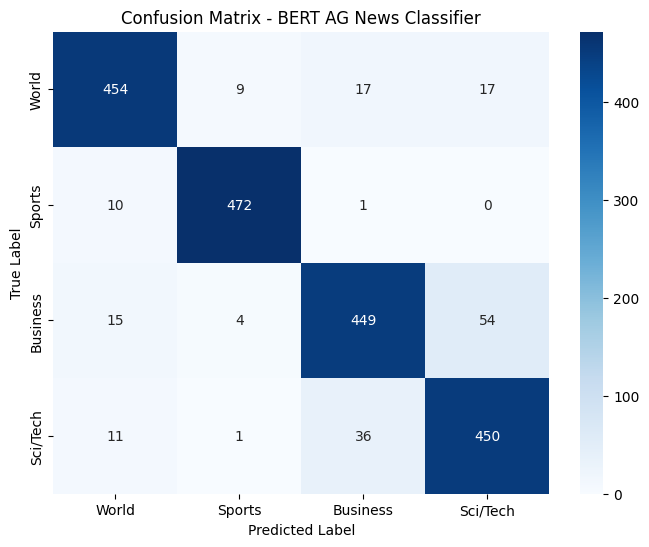

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.title("Confusion Matrix - BERT AG News Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [30]:
from transformers import BertTokenizerFast
import torch

def predict_news_topic(text):
    # Re-define label names in case they were lost in the session
    labels = ["World", "Sports", "Business", "Sci/Tech"]

    # Ensure tokenizer is defined locally
    local_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
    inputs = local_tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    # Move inputs to the same device as model
    inputs = {key: value.to(model.device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted_class].item()

    return labels[predicted_class], confidence

headline = "Iran and USA made a peace deal on opening Strait of Hormus"
category, confidence = predict_news_topic(headline)

print("Headline:", headline)
print("Predicted Category:", category)
print("Confidence:", f"{confidence:.4f}")

Headline: Iran and USA made a peace deal on opening Strait of Hormus
Predicted Category: World
Confidence: 0.9991


In [31]:
model.save_pretrained("saved_model")
tokenizer.save_pretrained("saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_model/tokenizer_config.json', 'saved_model/tokenizer.json')

In [32]:
import shutil

shutil.make_archive("bert_agnews_saved_model", "zip", "saved_model")

'/content/bert_agnews_saved_model.zip'

In [33]:
from google.colab import files

files.download("bert_agnews_saved_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>